## Hypothesis 3: Moran is insensitive to amplitude, Capy and dissimilarity are sensitive, therefore they show different values (trends?)

Moran’s I measures the spatial pattern of deviations from the citywide mean, not the absolute size of those deviations. This notebook tests if this is an explanation for why Half Edge trends can look more like dissimilarity than Moran.

We create a version of graphs that keeps each CBSA graph and tract population fixed, but scales every tract's POC share `p_i` toward the CBSA-wide POC share `p_bar`:

`p_i(alpha) = p_bar + alpha * (p_i - p_bar)`

For `alpha=1`, the graph is exactly as observed. For smaller `alpha`, the spatial pattern is the same but the amplitude of tract share differences is compressed. Moran should be invariant for `alpha > 0`; dissimilarity and edge-only Half Edge should respond to the change.

+ Test 1: Scale the amplitude down and see how they all react.

+ Test 2: Scale the amplitude down and see if how much Dissimilarity falls is associated with how much Half Edge falls (correlations).

+ Test 3: Does the amplitude actually change in the real world? If not, that’s not what’s driving the diverging trend


In [44]:
from pathlib import Path

from IPython.display import display
import gerrychain
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

project_root = Path.cwd().parent
csv_path = project_root / "outputs/tracts_in_cbsa/white_black.csv"

X_COL = "BLACK"
Y_COL = "WHITE"
TOT_COL = "TOTPOP"
ALPHAS = np.array([0.0, 0.1, 0.25, 0.5, 0.75, 1.0])

# Keys are counterfactual column names — used by all plotting cells.
# CSV column names (dissimilarity_1, moran_P, half_edge_exact_1) only appear in the validation cell.
METRIC_LABELS = {
    "dissimilarity": "Dissimilarity",
    "half_edge_lam_0_angle_1": "Half Edge (λ=0)",
    "moran": "Moran",
}
METRIC_COLORS = {
    "dissimilarity": "#4C78A8",
    "half_edge_lam_0_angle_1": "#F58518",
    "moran": "#54A24B",
}

In [45]:
df = pd.read_csv(csv_path)

df["year"] = df["filename"].str.extract(r"study_areas/(\d{4})/").astype(int)
df["cbsa"] = df["filename"].str.extract(r"tracts_in_cbsa_(\d+)_")
df["area_key"] = df["year"].astype(str) + " CBSA " + df["cbsa"]

metric_rows = df.dropna(subset=["dissimilarity_1", "moran_P", "half_edge_exact_1"]).copy()
metric_rows["graph_path"] = metric_rows["filename"].apply(lambda fn: project_root / fn)

# missing = metric_rows.loc[~metric_rows["graph_path"].apply(Path.exists), "graph_path"]
# if len(missing):
#     raise FileNotFoundError(f"Missing graph JSONs: {missing.head().tolist()}")

print(f"Loaded {len(metric_rows):,} White-POC tract CBSA rows.")
metric_rows[
    ["area_key", "total_population", "total_nodes", "total_edges",
     "dissimilarity_1", "moran_P", "half_edge_exact_1"]
].head()

Loaded 1,939 White-POC tract CBSA rows.


,area_key,total_population,total_nodes,total_edges,dissimilarity_1,moran_P,half_edge_exact_1
0,2020 CBSA 14540,179639,44,107,0.484534,0.213797,0.533887
1,2020 CBSA 26380,207137,60,164,0.438911,0.325792,0.538340
2,2020 CBSA 22520,150791,41,101,0.418184,0.239863,0.527752
3,2020 CBSA 23900,103852,27,58,0.311980,0.528575,0.503427
4,2020 CBSA 42700,101235,33,78,0.420530,0.197957,0.524001


## Scale Composition Amplitude

For each graph, `p_bar` is the population-weighted CBSA-wide POC share. Scaling around this value keeps the total POC and White counts fixed while compressing differences across tracts.

`p_i(alpha) = p_bar + alpha * (p_i - p_bar)`

At `alpha=0`, every tract has the same POC share, so dissimilarity is zero, edge-only Half Edge is `0.5`, and Moran is undefined because the share variance is zero.

In [46]:
counterfactual_records = []

for row_number, area in enumerate(metric_rows.itertuples(index=False), start=1):
    graph = gerrychain.Graph.from_json(area.graph_path)
    node_order = list(graph.nodes())
    node_index = {node: index for index, node in enumerate(node_order)}
    edge_indices = [(node_index[u], node_index[v]) for u, v in graph.edges()]

    observed_x = np.array([float(graph.nodes[node][X_COL]) for node in node_order], dtype=float)
    observed_y = np.array([float(graph.nodes[node][Y_COL]) for node in node_order], dtype=float)
    tract_totals = observed_x + observed_y
    valid_total = tract_totals > 0
    if not valid_total.all():
        raise ValueError(f"Found zero-population nodes in {area.filename}")

    observed_share = observed_x / tract_totals
    metro_share = observed_x.sum() / tract_totals.sum()

    for alpha in ALPHAS:
        scaled_share = metro_share + alpha * (observed_share - metro_share)
        if scaled_share.min() < -1e-12 or scaled_share.max() > 1 + 1e-12:
            raise ValueError(f"Scaled shares outside [0, 1] for {area.area_key}, alpha={alpha}")
        scaled_share = np.clip(scaled_share, 0, 1)

        x_counts = scaled_share * tract_totals
        y_counts = (1 - scaled_share) * tract_totals
        total_x = x_counts.sum()
        total_population = tract_totals.sum()

        dissimilarity_numerator = np.abs(
            x_counts * total_population - tract_totals * total_x
        ).sum()
        dissimilarity_denominator = 2 * total_x * (total_population - total_x)
        dissimilarity = dissimilarity_numerator / dissimilarity_denominator

        moran_mean = scaled_share.mean()
        moran_bottom = ((scaled_share - moran_mean) ** 2).sum()
        moran_top = 0.0
        for node_index_a, node_index_b in edge_indices:
            moran_top += (scaled_share[node_index_a] - moran_mean) * (
                scaled_share[node_index_b] - moran_mean
            )
        moran = (
            (len(node_order) / len(edge_indices)) * (moran_top / moran_bottom)
            if moran_bottom > 1e-24
            else np.nan
        )

        between_xx = 0.0
        between_xy = 0.0
        between_yy = 0.0
        for node_index_a, node_index_b in edge_indices:
            x_a = x_counts[node_index_a]
            y_a = y_counts[node_index_a]
            x_b = x_counts[node_index_b]
            y_b = y_counts[node_index_b]

            between_xx += x_a * x_b + x_b * x_a
            between_xy += x_a * y_b + x_b * y_a
            between_yy += y_a * y_b + y_b * y_a

        half_edge_lam_0_angle_1 = 0.5 * (
            between_xx / (between_xx + between_xy)
            + between_yy / (between_yy + between_xy)
        )

        counterfactual_records.append(
            {
                "area_key": area.area_key,
                "year": area.year,
                "cbsa": area.cbsa,
                "filename": area.filename,
                "alpha": alpha,
                "metro_share": metro_share,
                "dissimilarity": dissimilarity,
                "moran": moran,
                "half_edge_lam_0_angle_1": half_edge_lam_0_angle_1,
                "between_xx": between_xx,
                "between_xy": between_xy,
                "between_yy": between_yy,
            }
        )

    # if row_number % 100 == 0:
    #     print(f"Processed {row_number:,} graph JSONs...")

counterfactual = pd.DataFrame(counterfactual_records)
print(f"Built {len(counterfactual):,} counterfactual metric rows.")
counterfactual.head()

Built 11,634 counterfactual metric rows.


,area_key,year,cbsa,filename,alpha,metro_share,dissimilarity,moran,half_edge_lam_0_angle_1,between_xx,between_xy,between_yy
0,2020 CBSA 14540,2020,14540,study_areas/2020/tracts_in_cbsa_14540_2020_mar...,0.00,0.085922,7.430409e-17,NaN,0.500000,2.177906e+07,2.316953e+08,2.464877e+09
1,2020 CBSA 14540,2020,14540,study_areas/2020/tracts_in_cbsa_14540_2020_mar...,0.10,0.085922,4.845344e-02,0.308329,0.500318,2.238381e+07,2.337315e+08,2.460199e+09
2,2020 CBSA 14540,2020,14540,study_areas/2020/tracts_in_cbsa_14540_2020_mar...,0.25,0.085922,1.211336e-01,0.308329,0.501958,2.385688e+07,2.362199e+08,2.453750e+09
3,2020 CBSA 14540,2020,14540,study_areas/2020/tracts_in_cbsa_14540_2020_mar...,0.50,0.085922,2.422672e-01,0.308329,0.507655,2.782117e+07,2.388580e+08,2.444509e+09
4,2020 CBSA 14540,2020,14540,study_areas/2020/tracts_in_cbsa_14540_2020_mar...,0.75,0.085922,3.634008e-01,0.308329,0.516849,3.367193e+07,2.396096e+08,2.437155e+09


## Validate `alpha=1`

At `alpha=1` the counterfactual formulas should reproduce the CSV values. Only dissimilarity is asserted: it is unambiguous regardless of implementation choices. `moran_P` uses row-stochastic weights (1/degree) while the loop uses plain adjacency weights; `half_edge_exact_1` is a different variant than `half_edge_lam_0_angle_1`. Both mismatches are expected and do not affect the experiment.

In [47]:
alpha1 = counterfactual[counterfactual["alpha"].eq(1.0)][
    ["area_key", "dissimilarity", "moran", "half_edge_lam_0_angle_1"]
].merge(
    metric_rows[["area_key", "dissimilarity_1", "moran_P", "half_edge_exact_1"]],
    on="area_key",
    validate="one_to_one",
)

pairs = [
    ("dissimilarity", "dissimilarity_1", True),   # assert: unambiguous formula
    ("moran", "moran_P", False),                   # display only: different weight matrix
    ("half_edge_lam_0_angle_1", "half_edge_exact_1", False),  # display only: different variant
]

validation = pd.DataFrame([
    {"cf": cf, "csv": csv, "assert": do_assert,
     "max_abs_error": (alpha1[cf] - alpha1[csv]).abs().max(),
     "median_abs_error": (alpha1[cf] - alpha1[csv]).abs().median()}
    for cf, csv, do_assert in pairs
])
display(validation)

if validation.loc[validation["assert"], "max_abs_error"].max() > 1e-10:
    raise AssertionError("Counterfactual dissimilarity does not match the CSV")

,cf,csv,assert,max_abs_error,median_abs_error
0,dissimilarity,dissimilarity_1,True,2.220446e-16,0.000000
1,moran,moran_P,False,5.004678e-01,0.026072
2,half_edge_lam_0_angle_1,half_edge_exact_1,False,7.683152e-02,0.006611


## Plot Helper: Faint CBSA Lines

`plot_cbsa_lines` draws one line per group at very low opacity, then overlays a thick colored mean line. Used throughout Tests 1 and 3 to show the distribution of individual CBSA responses alongside the cross-CBSA trend.

In [48]:
def plot_cbsa_lines(data, x_col, y_col, group_col, ax, color, label=None,
                    alpha_lines=0.05, lw_lines=0.6, lw_mean=2.5, mean_marker="o"):
    """Individual group lines at very low opacity; thick mean line on top."""
    for _, group in data.groupby(group_col):
        group_sorted = group.sort_values(x_col)
        ax.plot(
            group_sorted[x_col], group_sorted[y_col],
            color=color, alpha=alpha_lines, linewidth=lw_lines, zorder=1,
        )
    mean_vals = data.groupby(x_col)[y_col].mean().reset_index().sort_values(x_col)
    ax.plot(
        mean_vals[x_col], mean_vals[y_col],
        color=color, linewidth=lw_mean, marker=mean_marker, markersize=5,
        label=label, zorder=2,
    )

## Test 1: Scale the amplitude down and see how metrics react

`p_i(alpha) = p_bar + alpha * (p_i - p_bar)`

Moran should be invariant for `alpha > 0` because it normalizes by the variance of tract shares. Dissimilarity and edge-only Half Edge should respond because they depend on absolute compositional differences.

Normalized response:
- `D(alpha) / D(1)` — Dissimilarity; zero at alpha=0 by definition
- `(HE0(alpha) − 0.5) / (HE0(1) − 0.5)` — Half Edge excess above the neutral baseline of 0.5
- `Moran(alpha) − Moran(1)` — should be numerical noise for all positive alpha

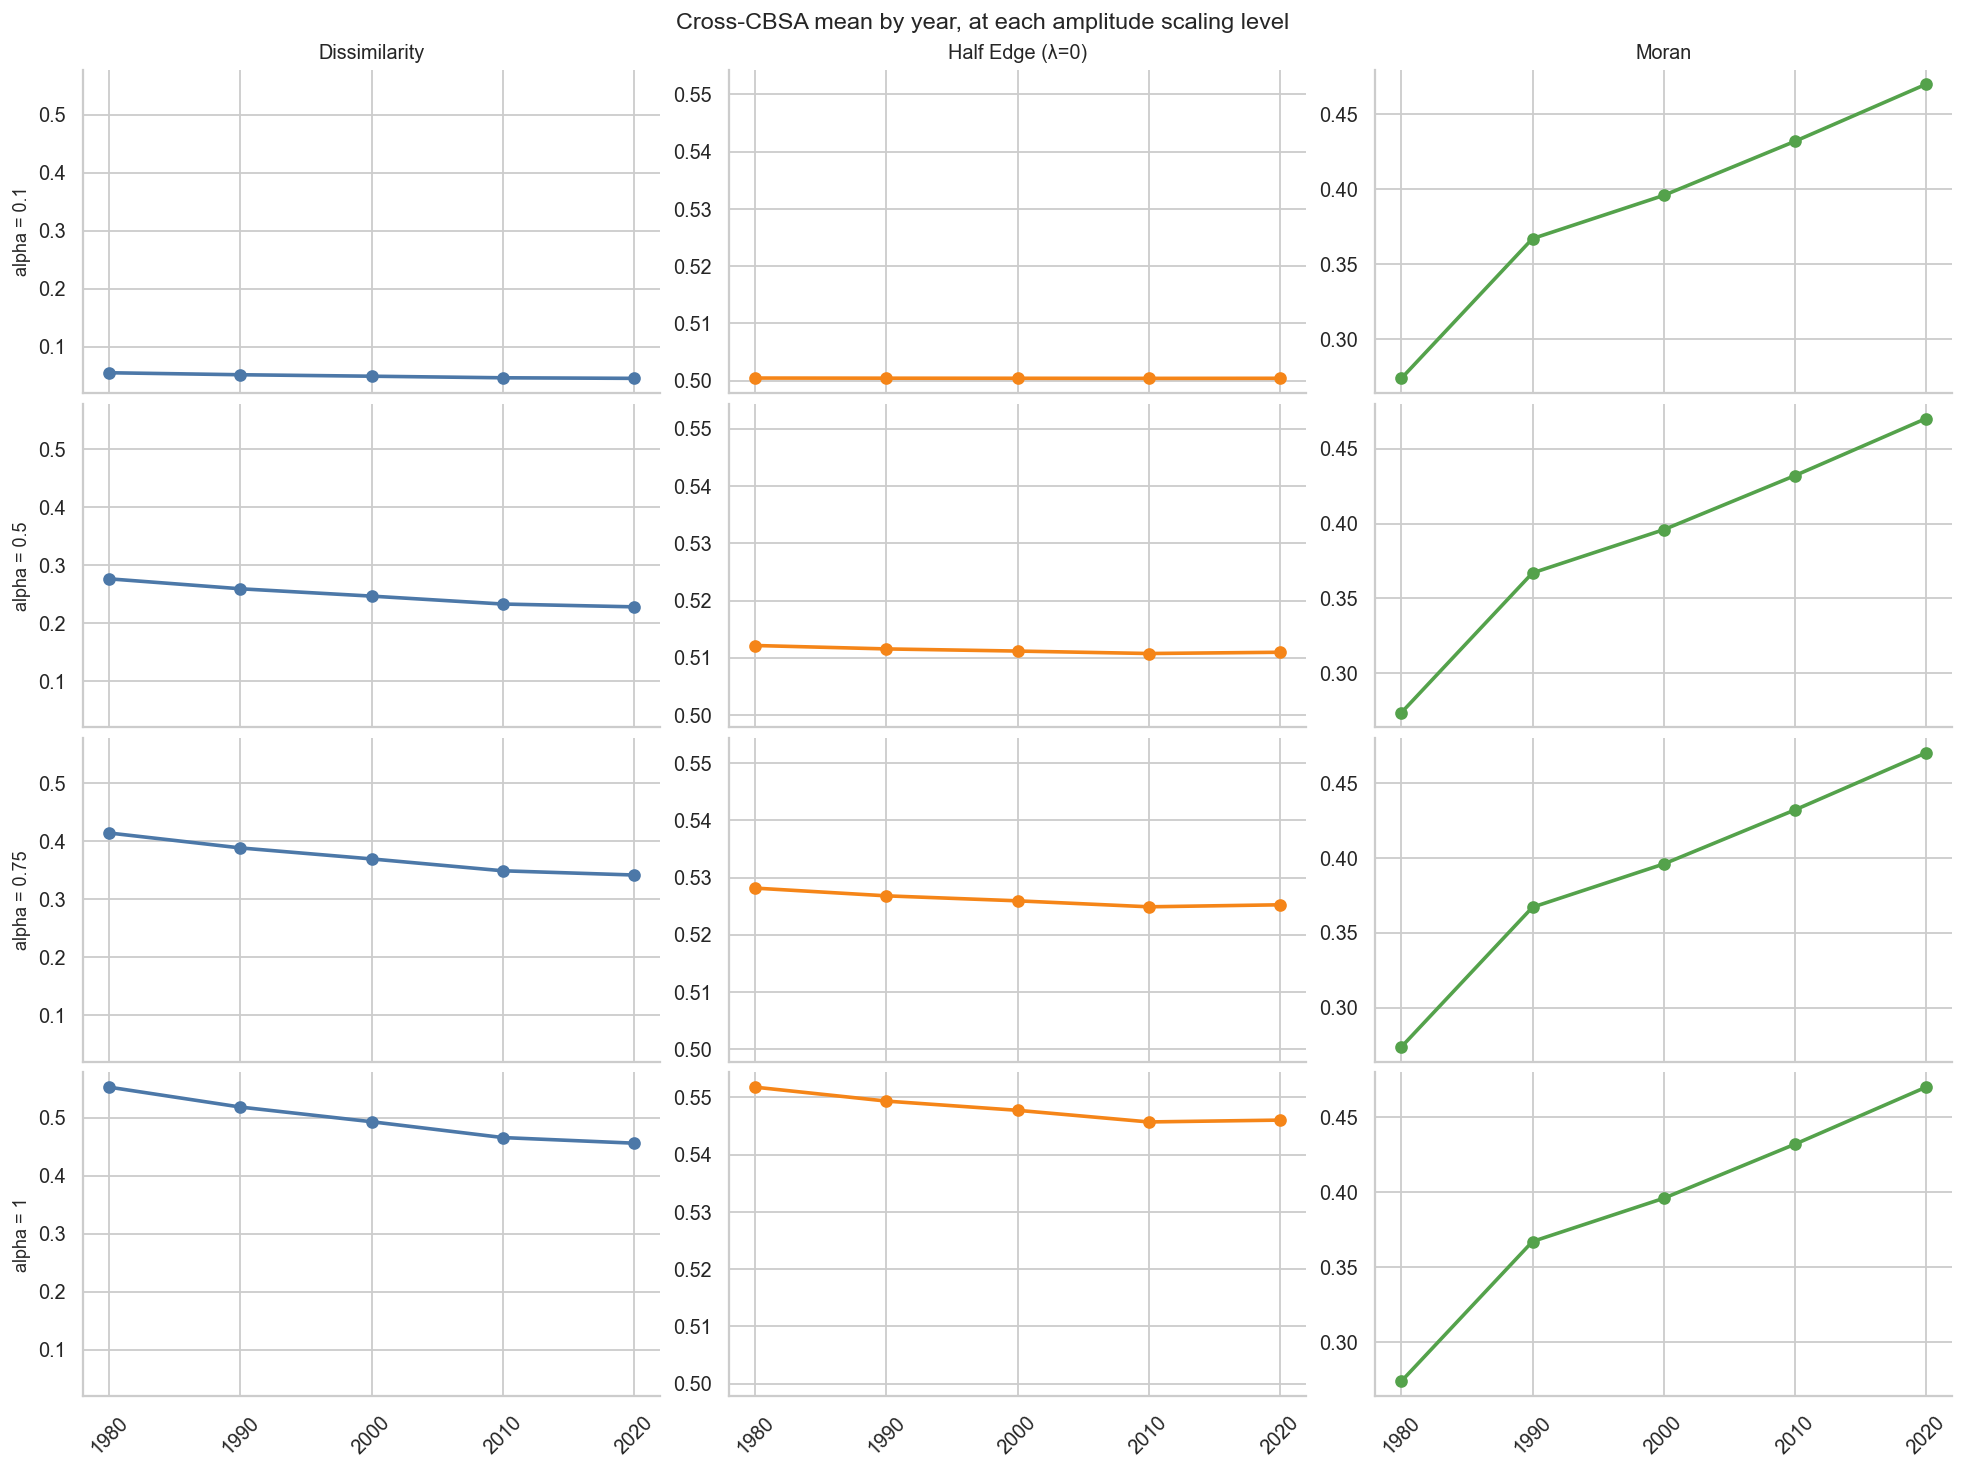

In [49]:
alphas_grid = [0.1, 0.5, 0.75, 1.0]
metrics = list(METRIC_LABELS)

year_means = (
    counterfactual[counterfactual["alpha"].isin(alphas_grid)]
    .groupby(["alpha", "year"], as_index=False)[metrics]
    .mean()
)
year_values = sorted(year_means["year"].unique())

fig, axes = plt.subplots(
    nrows=len(alphas_grid),
    ncols=len(metrics),
    figsize=(5 * len(metrics), 2.8 * len(alphas_grid)),
    constrained_layout=True,
    sharex=True,
    sharey="col",
)

for col_idx, (metric, label) in enumerate(METRIC_LABELS.items()):
    color = METRIC_COLORS[metric]
    for row_idx, alpha in enumerate(alphas_grid):
        ax = axes[row_idx, col_idx]
        data = year_means[year_means["alpha"].eq(alpha)]
        ax.plot(data["year"], data[metric], marker="o", color=color, linewidth=2)
        ax.set_xticks(year_values)
        ax.tick_params(axis="x", rotation=45)
        if col_idx == 0:
            ax.set_ylabel(f"alpha = {alpha:g}", fontsize=10)
        if row_idx == 0:
            ax.set_title(label, fontsize=11)

fig.suptitle("Cross-CBSA mean by year, at each amplitude scaling level", fontsize=13)
plt.show()

In [50]:
observed_by_area = counterfactual[counterfactual["alpha"].eq(1.0)].set_index("area_key")

counterfactual["observed_dissimilarity"] = counterfactual["area_key"].map(
    observed_by_area["dissimilarity"]
)
counterfactual["observed_moran"] = counterfactual["area_key"].map(observed_by_area["moran"])
counterfactual["observed_half_edge_lam_0_angle_1"] = counterfactual["area_key"].map(
    observed_by_area["half_edge_lam_0_angle_1"]
)

counterfactual["dissimilarity_ratio"] = (
    counterfactual["dissimilarity"] / counterfactual["observed_dissimilarity"]
)
counterfactual["he0_excess"] = counterfactual["half_edge_lam_0_angle_1"] - 0.5
counterfactual["observed_he0_excess"] = (
    counterfactual["observed_half_edge_lam_0_angle_1"] - 0.5
)
counterfactual["he0_excess_ratio"] = np.where(
    counterfactual["observed_he0_excess"].abs() > 1e-12,
    counterfactual["he0_excess"] / counterfactual["observed_he0_excess"],
    np.nan,
)
counterfactual["moran_delta"] = counterfactual["moran"] - counterfactual["observed_moran"]
counterfactual["moran_abs_delta"] = counterfactual["moran_delta"].abs()

alpha_summary = (
    counterfactual.groupby("alpha")
    .agg(
        dissimilarity_ratio_median=("dissimilarity_ratio", "median"),
        dissimilarity_ratio_p10=("dissimilarity_ratio", lambda values: values.quantile(0.10)),
        dissimilarity_ratio_p90=("dissimilarity_ratio", lambda values: values.quantile(0.90)),
        he0_excess_ratio_median=("he0_excess_ratio", "median"),
        he0_excess_ratio_p10=("he0_excess_ratio", lambda values: values.quantile(0.10)),
        he0_excess_ratio_p90=("he0_excess_ratio", lambda values: values.quantile(0.90)),
        moran_abs_delta_median=("moran_abs_delta", "median"),
        moran_abs_delta_max=("moran_abs_delta", "max"),
    )
    .reset_index()
)

alpha_summary

,alpha,dissimilarity_ratio_median,dissimilarity_ratio_p10,dissimilarity_ratio_p90,he0_excess_ratio_median,he0_excess_ratio_p10,he0_excess_ratio_p90,moran_abs_delta_median,moran_abs_delta_max
0,0.00,6.241911e-17,1.480854e-17,2.244725e-16,0.000000,-2.538256e-15,1.165978e-15,NaN,NaN
1,0.10,1.000000e-01,1.000000e-01,1.000000e-01,0.009455,8.141748e-03,1.040500e-02,1.665335e-16,8.104628e-15
2,0.25,2.500000e-01,2.500000e-01,2.500000e-01,0.059619,5.249654e-02,6.459299e-02,6.938894e-17,1.221245e-15
3,0.50,5.000000e-01,5.000000e-01,5.000000e-01,0.242139,2.216642e-01,2.555076e-01,5.551115e-17,5.551115e-16
4,0.75,7.500000e-01,7.500000e-01,7.500000e-01,0.553507,5.284458e-01,5.686070e-01,1.110223e-16,6.106227e-15
5,1.00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00


### All CBSA-years: metrics vs. alpha

Each faint line is one CBSA-year; the thick line is the cross-CBSA-year mean at each alpha. This shows how consistently each metric responds to amplitude compression across the full distribution of metros.

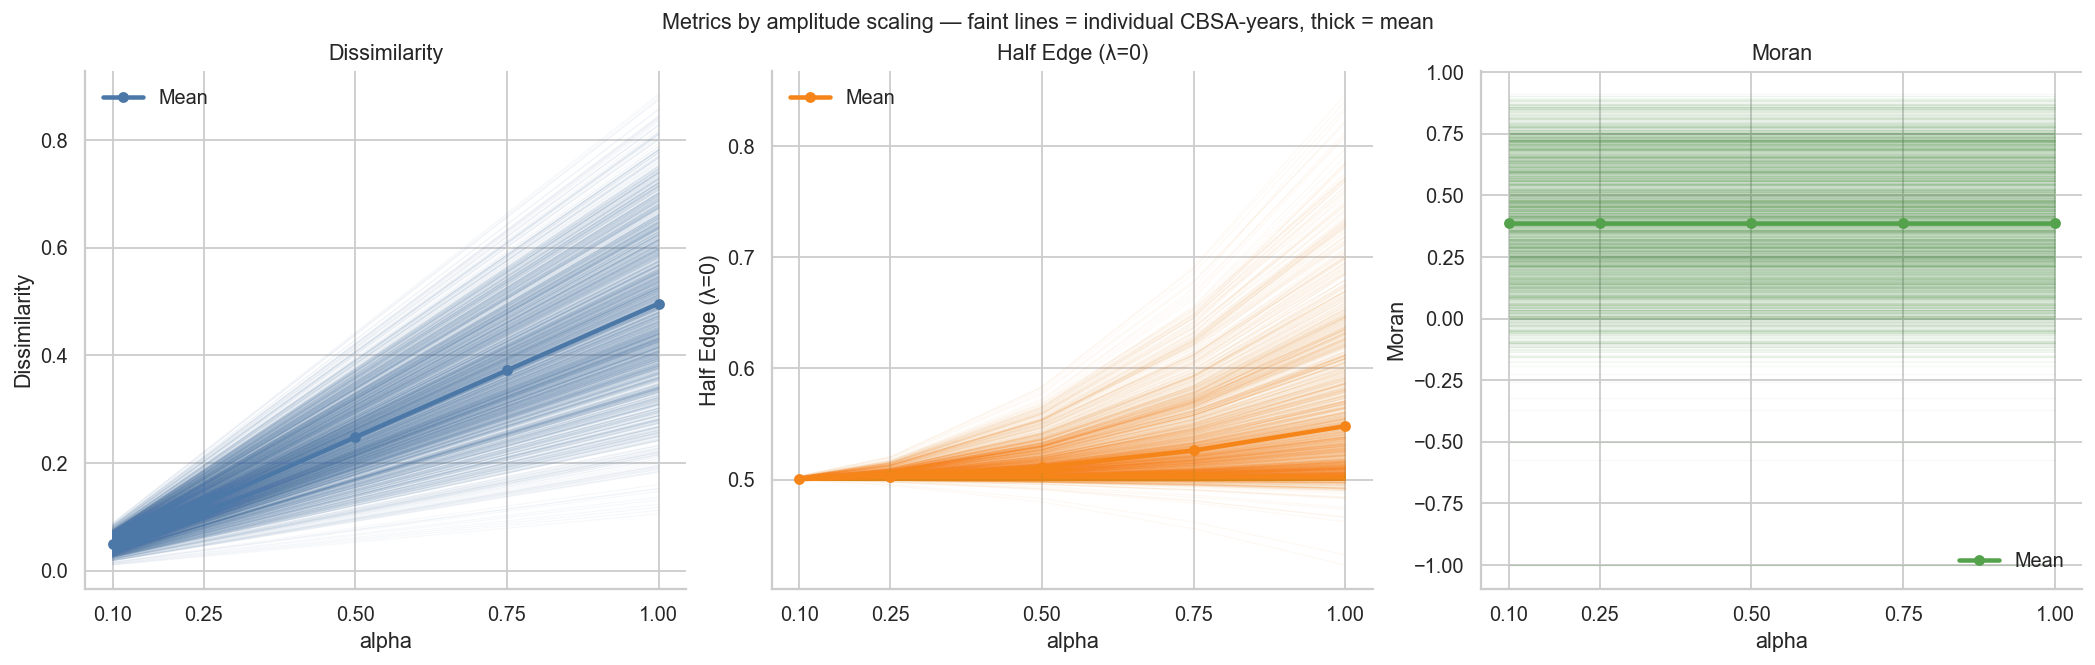

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

for ax, (metric, label) in zip(axes, METRIC_LABELS.items()):
    color = METRIC_COLORS[metric]
    metric_data = counterfactual.loc[
        counterfactual["alpha"].gt(0), ["area_key", "alpha", metric]
    ].dropna()
    plot_cbsa_lines(
        metric_data, x_col="alpha", y_col=metric, group_col="area_key",
        ax=ax, color=color, label="Mean",
    )
    ax.set_xlabel("alpha")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticks(ALPHAS[ALPHAS > 0])
    ax.legend(frameon=False)

fig.suptitle(
    "Metrics by amplitude scaling — faint lines = individual CBSA-years, thick = mean",
    fontsize=12,
)
plt.show()

## Test 2: Is how HE loses values related with how Dissimilarity loses values, as we scale alpha down?

### What the graph shows

**Two lines show ratio to observed value:**

- **Dissimilarity (blue)**: `D(α) / D(1)` — how much of its observed value dissimilarity retains at each alpha. Because D is exactly linear in alpha, this ratio equals alpha for *every* CBSA. The blue line is a perfect diagonal and has no cross-CBSA spread.

- **Half Edge excess (orange)**: `(HE(α) − 0.5) / (HE(1) − 0.5)` — how much of Half Edge's *excess above its neutral baseline of 0.5* is retained. The 0.5 subtraction is necessary because HE equals 0.5 when all tracts have identical shares, so the meaningful quantity is how far above that floor it sits. This line shows the cross-CBSA mean.

### What to look for

If HE tracked D perfectly, the orange line would lie exactly on the blue diagonal — both metrics would lose the same fraction of their value at every alpha. A curve **below** the diagonal means HE is less sensitive to amplitude compression than D: at the same alpha, HE retains more of its observed value than D does. This is expected from the formula — HE's edge products are quadratic in tract shares, not linear, so the response is slower.

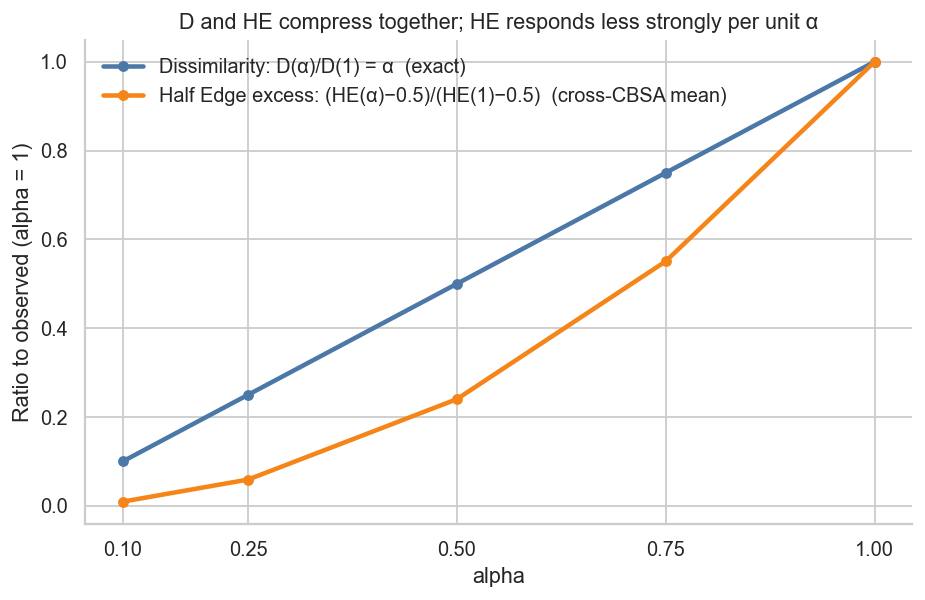

In [55]:
pos = counterfactual[counterfactual["alpha"].gt(0)].dropna(subset=["he0_excess_ratio"])
he_mean = pos.groupby("alpha")["he0_excess_ratio"].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)

ax.plot(
    ALPHAS[ALPHAS > 0], ALPHAS[ALPHAS > 0],
    color=METRIC_COLORS["dissimilarity"], linewidth=2.5, marker="o", markersize=5,
    label="Dissimilarity: D(α)/D(1) = α  (exact)",
)
ax.plot(
    he_mean["alpha"], he_mean["he0_excess_ratio"],
    color=METRIC_COLORS["half_edge_lam_0_angle_1"], linewidth=2.5, marker="o", markersize=5,
    label="Half Edge excess: (HE(α)−0.5)/(HE(1)−0.5)  (cross-CBSA mean)",
)

ax.set_xlabel("alpha")
ax.set_ylabel("Ratio to observed (alpha = 1)")
ax.set_title("D and HE compress together; HE responds less strongly per unit α")
ax.set_xticks(ALPHAS[ALPHAS > 0])
ax.legend(frameon=False)
plt.show()

## Test 3: Does amplitude actually change in the real world?

**Observed amplitude** is the population-weighted average deviation of tract POC shares from the metro mean:

`amplitude = Σ_i (t_i / N) × |p_i − p̄|`

where `t_i` is tract population, `N` is metro total, `p_i` is tract POC share, and `p̄` is the metro-wide POC share.

If this quantity is declining over time, both Dissimilarity and Half Edge would fall (they are sensitive to amplitude) while Moran would not (it normalizes amplitude out). That would be a concrete mechanism for the observed divergence between metrics.

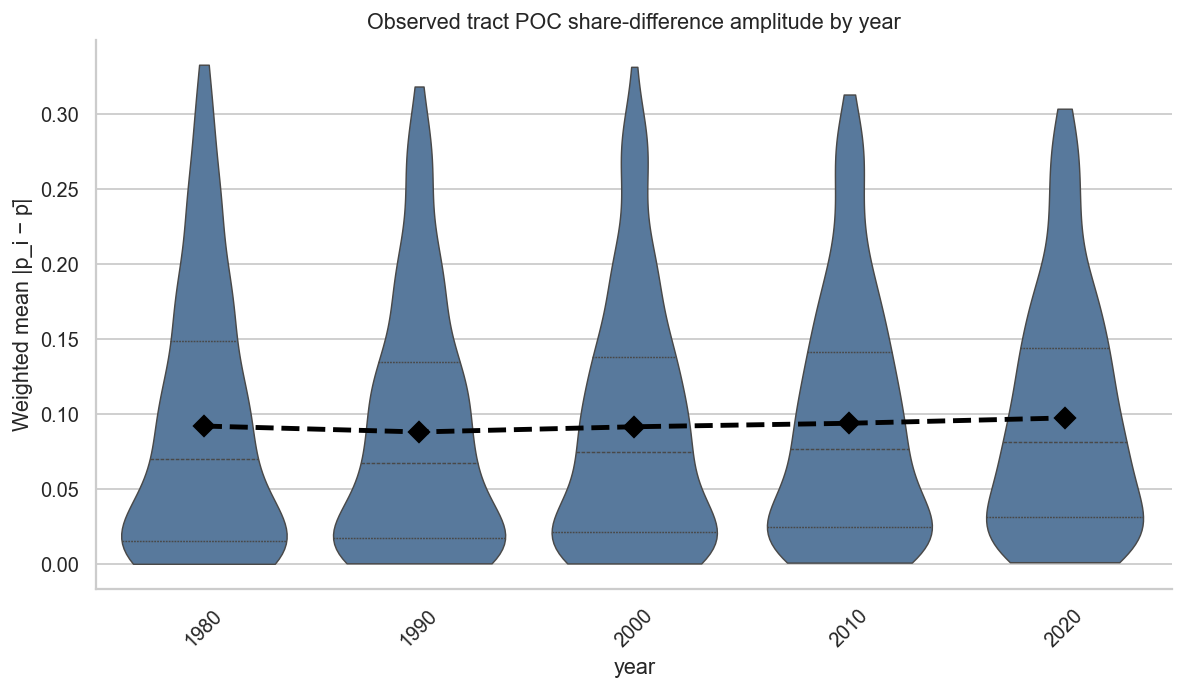

,year,count,mean,std,min,10%,25%,50%,75%,90%,max
0,1980,379.0,0.0921,0.0861,0.0003,0.0031,0.0152,0.0703,0.1488,0.2316,0.3329
1,1990,384.0,0.0881,0.0803,0.0006,0.0042,0.0177,0.0676,0.1347,0.2045,0.3184
2,2000,392.0,0.0916,0.0807,0.0005,0.0063,0.0216,0.0749,0.1378,0.2057,0.3315
3,2010,392.0,0.0940,0.0790,0.0011,0.0084,0.0252,0.0768,0.1415,0.2106,0.3130
4,2020,392.0,0.0975,0.0769,0.0014,0.0109,0.0312,0.0817,0.1443,0.2151,0.3036


In [59]:
counterfactual["poc_share_amplitude"] = (
    counterfactual["dissimilarity"]
    * 2
    * counterfactual["metro_share"]
    * (1 - counterfactual["metro_share"])
)

observed_amplitude = counterfactual[counterfactual["alpha"].eq(1.0)].copy()
observed_amplitude["year_label"] = observed_amplitude["year"].astype(str)
year_labels = [str(y) for y in sorted(observed_amplitude["year"].unique())]

fig, ax = plt.subplots(figsize=(9, 5.2), constrained_layout=True)
sns.violinplot(
    data=observed_amplitude,
    x="year_label",
    y="poc_share_amplitude",
    order=year_labels,
    inner="quartile",
    cut=0,
    linewidth=0.8,
    color=METRIC_COLORS["dissimilarity"],
    ax=ax,
)
sns.pointplot(
    data=observed_amplitude,
    x="year_label",
    y="poc_share_amplitude",
    order=year_labels,
    estimator="mean",
    errorbar=None,
    color="black",
    markers="D",
    linestyles="--",
    ax=ax,
)
ax.set_xlabel("year")
ax.set_ylabel("Weighted mean |p_i − p̄|")
ax.set_title("Observed tract POC share-difference amplitude by year")
ax.tick_params(axis="x", rotation=45)
plt.show()

amplitude_summary = (
    observed_amplitude.groupby("year")["poc_share_amplitude"]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    .reset_index()
)
display(amplitude_summary.round(4))

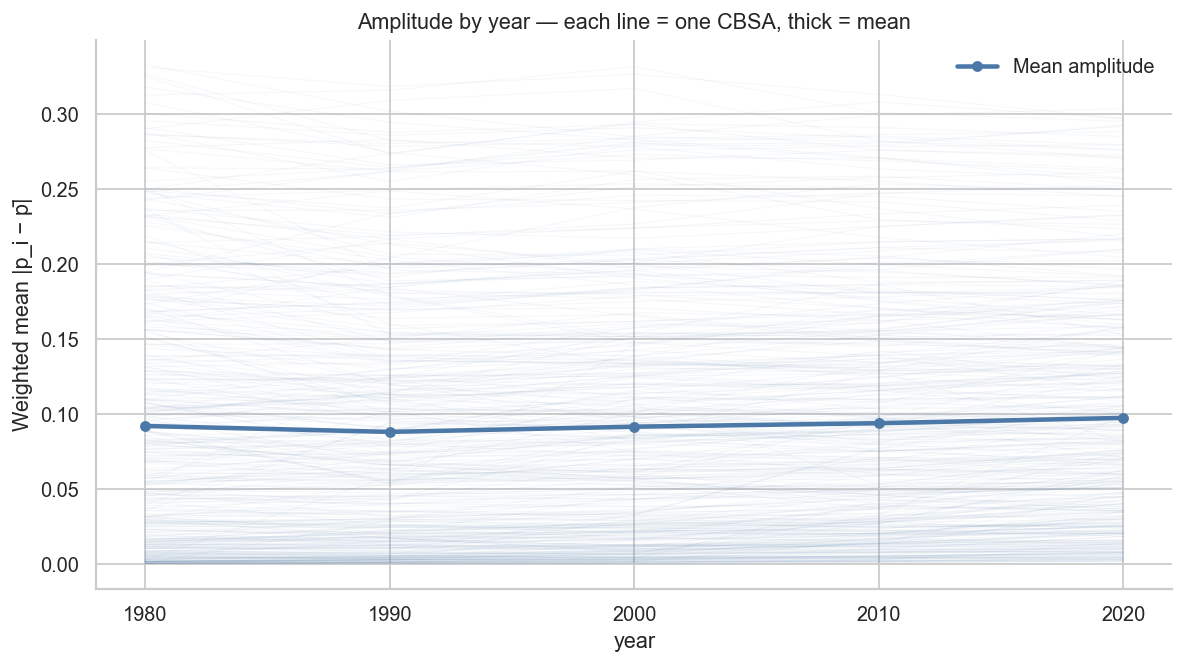

In [60]:
cbsa_year_counts = observed_amplitude.groupby("cbsa")["year"].nunique()
multi_year_cbsas = cbsa_year_counts[cbsa_year_counts > 1].index
amp_multi = observed_amplitude[observed_amplitude["cbsa"].isin(multi_year_cbsas)]

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
plot_cbsa_lines(
    amp_multi, x_col="year", y_col="poc_share_amplitude", group_col="cbsa",
    ax=ax, color=METRIC_COLORS["dissimilarity"], label="Mean amplitude",
)
ax.set_xlabel("year")
ax.set_ylabel("Weighted mean |p_i − p̄|")
ax.set_title("Amplitude by year — each line = one CBSA, thick = mean")
ax.set_xticks(sorted(amp_multi["year"].unique()))
ax.legend(frameon=False)
plt.show()

### Bonus: HE − Moran divergence vs. amplitude

If amplitude drives the gap between Half Edge and Moran, metros with larger amplitude should show a larger raw HE − Moran difference. This cross-sectional scatter tests that relationship at alpha=1 (observed data).

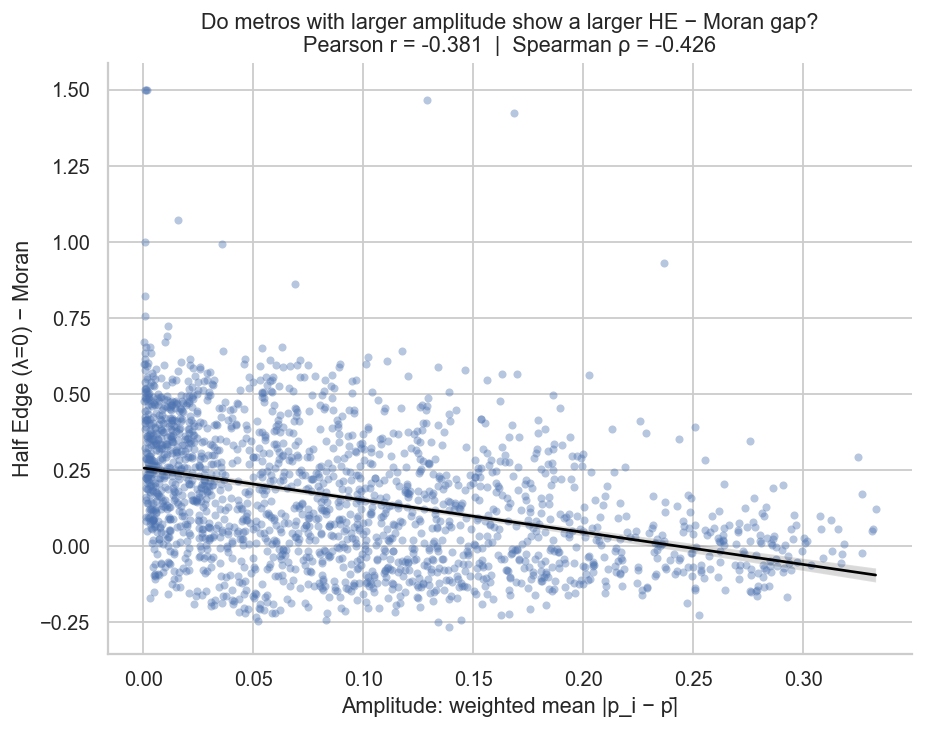

In [61]:
obs = counterfactual[counterfactual["alpha"].eq(1.0)].copy()
obs["he_minus_moran"] = obs["half_edge_lam_0_angle_1"] - obs["moran"]

r_div = obs[["poc_share_amplitude", "he_minus_moran"]].corr().iloc[0, 1]
rho_div = obs[["poc_share_amplitude", "he_minus_moran"]].corr(method="spearman").iloc[0, 1]

fig, ax = plt.subplots(figsize=(7, 5.5), constrained_layout=True)
sns.regplot(
    data=obs,
    x="poc_share_amplitude",
    y="he_minus_moran",
    scatter_kws={"s": 20, "alpha": 0.4, "linewidths": 0},
    line_kws={"color": "black", "linewidth": 1.5},
    ax=ax,
)
ax.set_xlabel("Amplitude: weighted mean |p_i − p̄|")
ax.set_ylabel("Half Edge (λ=0) − Moran")
ax.set_title(
    "Do metros with larger amplitude show a larger HE − Moran gap?\n"
    f"Pearson r = {r_div:.3f}  |  Spearman ρ = {rho_div:.3f}"
)
plt.show()

Not true!

## Takeaway

**Test 1** confirms amplitude sensitivity: Moran stays fixed because it normalizes by the variance of tract shares. Dissimilarity falls proportionally with alpha. Edge-only Half Edge also moves — it sees segregation intensity that Moran intentionally normalizes away.

**Test 2** shows the response is correlated across metros: areas that lose more dissimilarity when amplitude is compressed also lose more Half Edge excess, and this holds across all tested alpha values. The edge-only component of Half Edge is tracking the same amplitude signal as dissimilarity.

**Test 3** asks whether this mechanism operates in real data. If amplitude is stable over time, amplitude change alone cannot explain a diverging Moran/Half Edge trend. And that's what we see.